<a href="https://colab.research.google.com/github/hoshi-3104-com/california-house-price-competition/blob/main/notebooks/01_house_price_EDA_hoshino.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 01. 探索的データ解析（EDA）およびデータの可視化（EDA & Visualization）


#### **1. 本ファイルの目的**
本ファイルの目的は、カリフォルニア住宅価格の訓練データ（train.csv）を様々な角度から統計的・視覚的に分析し, 「データの構造」や「特徴量と住宅価格（目的変数）の関係性」を深く理解する。


#### **2. 解析・可視化のアプローチ（やること）**

① データの基本構造の確認
行数・列数、各特徴量のデータ型、欠損値の有無を確認

② 基本統計量（describe）による分布と異常値の把握
各変数の平均値、中央値、最大値・最小値のバランスを確認し、データの偏りや極端な外れ値（異常値）などを確認

③ 目的変数（Price）と説明変数間の相関分析
相関係数を算出（絶対値順にソート）し、住宅価格に直接影響を与えている重要な変数を特定

④ 目的変数（Price）の正規性チェックと対数変換の検証
住宅価格の分布が綺麗にばらついているか（正規分布に近いか）を確認し、モデルの学習効率を上げるための対数変換の必要性を検討

⑤ 特徴量の個別散布図プロット（外れ値の特定）
基本統計量で異常が疑われた変数について、データインデックス（行番号）との散布図を描画し、具体的な外れ値の個数や行番号を特定

#### **0. kaggle API・データ・ライブラリの読み込み**

In [ ]:
# kaggle APIのインストール
!pip install kaggle

In [ ]:
# driveのマウント
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 日本語フォント用ライブラリ
!pip install japanize_matplotlib

In [ ]:
# Kaggle APIを利用できるようにするため、kaggle.jsonからusernameとkeyを設定する
import os
import json
f = open("/content/drive/MyDrive/house_price_competion_hoshino/kaggle.json", 'r') # ディレクトリは必要に応じて変更してください
json_data = json.load(f)
os.environ['KAGGLE_USERNAME'] = json_data['username']
os.environ['KAGGLE_KEY'] = json_data['key']

In [ ]:
# データのダウンロードと解凍
!kaggle competitions download -c ambl-california-housing
!unzip /content/ambl-california-housing.zip

ambl-california-housing.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/ambl-california-housing.zip
replace sample.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: sample.csv              
replace test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: test.csv                
replace train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: train.csv               


In [ ]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# 前処理(正規化・標準化)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# データ分割
from sklearn.model_selection import train_test_split

# 線形モデル
from sklearn.linear_model import LinearRegression

# 精度評価
from sklearn.metrics import mean_squared_error

# グラフをアウトプット行に出力するためのマジックコマンド
%matplotlib inline

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample = pd.read_csv('sample.csv')

In [ ]:
file_path_train = '/content/drive/MyDrive/house_price_competion_hoshino/train_data_raw.csv'
file_path_test = '/content/drive/MyDrive/house_price_competion_hoshino/test_data_raw.csv'
# 4. DataFrameをCSVとして保存
train.to_csv(file_path_train, index=False, encoding='utf-8')
test.to_csv(file_path_test, index=False, encoding='utf-8')

In [ ]:
file_path_sample = '/content/drive/MyDrive/house_price_competion_hoshino/sample_raw.csv'
sample.to_csv(file_path_sample, index=False, encoding='utf-8')


### 今回利用するデータ
#####  ・今回使うデータセットのカラムは以下の通り

|カラム名|意味|
|-|-|
|MedInc|ブロックの所得中央値|
|HouseAge|ブロックの家屋年齢の中央値|
|AveRooms|1世帯当たりの平均居室数|
|AveBedrms|1世帯当たりの平均寝室数|
|Population|ブロックの人口|
|AveOccup|平均世帯人口|
|Latitude|緯度|
|Longitude|経度|
|**Price**|住宅価格(目的変数)|

#### ① データの基本構造の確認

In [ ]:
# 各データの表示
print('\n--------train_data--------\n')
display(train.head())
print('\n--------test_data--------\n')
display(test.head())
print('\n--------sample_data--------\n')
display(sample.head())


--------train_data--------



,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
0,0,1.4817,6.0,4.443645,1.134293,1397.0,3.350120,36.77,-119.84,417.0,1853.0,473.0,0.720
1,1,6.9133,8.0,5.976471,1.026471,862.0,2.535294,33.68,-117.80,340.0,2032.0,349.0,2.741
2,2,1.5536,25.0,4.088785,1.000000,931.0,4.350467,36.60,-120.19,214.0,875.0,214.0,0.583
3,3,1.5284,31.0,2.740088,1.008811,597.0,2.629956,34.10,-118.32,227.0,622.0,229.0,2.000
4,4,4.0815,21.0,5.166667,1.002688,1130.0,3.037634,37.79,-121.23,372.0,1922.0,373.0,1.179



--------test_data--------



,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms
0,0,6.4114,15.0,7.527559,1.049869,2529.0,3.318898,33.60,-117.65,762.0,5736.0,800.0
1,1,4.1843,12.0,6.330084,1.041783,2033.0,2.831476,38.62,-120.91,718.0,4545.0,748.0
2,2,1.7411,35.0,5.369159,1.294393,909.0,4.247664,33.93,-118.23,214.0,1149.0,277.0
3,3,3.4412,39.0,4.173405,1.074573,2156.0,1.937107,37.59,-122.37,1113.0,4645.0,1196.0
4,4,7.8195,16.0,8.602349,1.058725,2142.0,3.593960,33.70,-117.98,596.0,5127.0,631.0



--------sample_data--------



,id,Price
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [ ]:
from IPython.display import display, Markdown

# 1. 行数・列数をMarkdownで綺麗に表示
display(Markdown(f"#### データ形状 (Shape)\n* **行数 (データ数):** `{train.shape[0]:,}` 行\n* **列数 (特徴量数):** `{train.shape[1]}` 列"))

# 2. 列ごとの情報を1つのデータフレームに集約
info_df = pd.DataFrame({
    'データ型 (dtypes)': train.dtypes,
    '欠損値数 (null)': train.isnull().sum(),
    '固有値数 (nunique)': train.nunique() # 何種類の値があるか
})

display(Markdown("#### 列ごとの情報サマリー"))
display(info_df)

#### データ形状 (Shape)
* **行数 (データ数):** `16,512` 行
* **列数 (特徴量数):** `13` 列

#### 列ごとの情報サマリー

,データ型 (dtypes),欠損値数 (null),固有値数 (nunique)
id,int64,0,16512
MedInc,float64,0,10900
HouseAge,float64,0,52
AveRooms,float64,0,15698
AveBedrms,float64,0,11966
Population,float64,0,3658
AveOccup,float64,0,15316
Latitude,float64,0,840
Longitude,float64,0,828
Household,float64,0,2185


#### ② 基本統計量（describe）による分布と異常値の把握

In [ ]:
# ④基本統計量(describe関数を利用します)
# 基本統計量：データの分布の特徴を記述したり要約するための必要な指標のことです。

train.describe()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price
count,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,8255.500000,3.864091,28.624516,5.412724,1.094586,1435.017260,3.080506,35.626523,-119.564046,501.135962,2644.170603,539.428537,2.065093
std,4766.748158,1.893244,12.597980,2.279264,0.449683,1158.151967,10.933679,2.139150,2.005033,385.650673,2213.946369,425.193556,1.152260
min,0.000000,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,2.000000,6.000000,2.000000,0.149990
25%,4127.750000,2.562500,18.000000,4.441027,1.006231,788.000000,2.430380,33.930000,-121.790000,280.000000,1446.000000,296.000000,1.194000
50%,8255.500000,3.531300,29.000000,5.224884,1.048420,1168.000000,2.821348,34.250000,-118.490000,410.000000,2116.000000,435.000000,1.793000
75%,12383.250000,4.733225,37.000000,6.047464,1.099243,1738.000000,3.290106,37.710000,-118.010000,606.000000,3154.000000,647.250000,2.645000
max,16511.000000,15.000100,52.000000,132.533333,34.066667,35682.000000,1243.333333,41.950000,-114.310000,6082.000000,39320.000000,6445.000000,5.000010


In [ ]:
test.describe()

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms
count,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.00000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,2063.500000,3.896990,28.699370,5.494101,1.105031,1387.31468,3.031253,35.653217,-119.592338,493.154554,2602.132994,531.775921
std,1191.795284,1.925917,12.537087,3.134380,0.560430,1022.51429,7.822054,2.123237,1.997596,368.723505,2047.102172,405.073401
min,0.000000,0.499900,2.000000,1.000000,0.500000,6.00000,0.970588,32.560000,-124.300000,1.000000,2.000000,1.000000
25%,1031.750000,2.573550,18.000000,4.438205,1.005355,784.00000,2.428501,33.950000,-121.820000,279.000000,1458.750000,295.000000
50%,2063.500000,3.559000,29.000000,5.258908,1.049650,1159.00000,2.809997,34.275000,-118.545000,408.000000,2160.500000,434.000000
75%,3095.250000,4.802475,37.000000,6.072188,1.100000,1682.25000,3.250000,37.720000,-118.010000,597.250000,3113.000000,644.000000
max,4127.000000,15.000100,52.000000,141.909091,25.636364,11956.00000,502.461538,41.840000,-114.470000,4930.000000,27870.000000,5419.000000


### 基本統計量から読み取れること：

#### **1. 目的変数（Price）の頭打ち（クリッピング現象）**

* 最大値の不自然さ: `Price`（住宅価格）の最大値が、きれいに **`5.00001`** で止まっている
* データの特徴: 75%タイルの値（データの上位25%の境界線）が `2.645` であるのに対し、最大値がこの中途半端な数値で固定されている。これは、ある一定額以上の高額住宅の価格がすべて `5.00001` として一律に丸め込まれていることを意味する。

#### **2. 特定の特徴量における極端な外れ値（異常値）**

データの75%が収まる範囲（75%タイル）に対して、最大値（max）が桁違いに大きい特徴量が複数存在。

* **AveRooms（平均居室数）**: 75%タイルが約 `6.0` に対し、最大値が `132.5`（1世帯130部屋以上は極端）。
* **AveBedrms（平均寝室数）**: 75%タイルが約 `1.1` に対し、最大値が `34.1`。
* **AveOccup（平均世帯人員）**: 75%タイルが約 `3.3` に対し、最大値が `1243.3`。※1200人を超える世帯人数は、誤データか、あるいは大規模な施設（寮やケアハウスなど）の可能性あり
* **Population（ブロック人口）**: 75%タイルが約 `1,738` に対し、最大値が `35,682`。

#### **3. 所得データ（MedInc）の分布の正常性**

* データのばらつき: `MedInc`（所得中央値）は、最小値 `0.50` から最大値 `15.00` の範囲にあり、平均は `3.86` です。
* 予測への期待: 標準偏差（std）が `1.89` と適度にばらついており、極端な偏りがないため、住宅価格を予測する上で最も強力な（相関の高い）メインの特徴量として機能することが推測できる

#### **4. 地理データ（Latitude / Longitude）の妥当性**

* 位置情報の範囲: 緯度（Latitude）が `32.54 〜 41.95`、経度（Longitude）が `-124.35 〜 -114.31` の範囲に位置している。
* データの正常性: これはアメリカ・カリフォルニア州の実際の地理的範囲と合致しており、位置情報データに明らかな入力エラー（全く違う国のデータが混ざるなど）が含まれていないことが確認できる。

---

#### **今後の前処理・モデル構築への反映方針**

* 外れ値の処理: `AveOccup` など、明らかに異常な値を持つデータは学習を阻害するため、行ごと除外するか、適切な上限値でクリッピングする処理を検討。
* 予測値の後処理: モデルの最終的な予測値が `5.00001` を超えた場合、またはマイナスになった場合に、データの本来の範囲（0〜5.00001）に丸める後処理を施すことで、スコアの向上が期待できる

こんなコード：pred_final = np.clip(pred, 0, 5.00001)




#### ③ 目的変数（Price）の正規性チェックと対数変換の検証

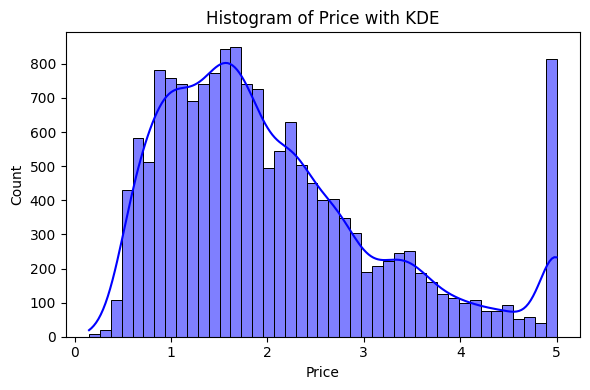

統計量: 1944.4813, p値: 0.0000
結論: p値が0.05未満のため、目的変数は正規分布とは言えません（歪んでいます）。


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. グラフによる確認（ヒストグラムのみを適切なサイズで表示）
fig, ax = plt.subplots(figsize=(6, 4))

# ヒストグラム（KDE曲線付き）
sns.histplot(train['Price'], kde=True, ax=ax, color='blue')
ax.set_title('Histogram of Price with KDE')

plt.tight_layout()
plt.show()

# 2. 統計的検定による確認（ダゴスティーノのK二乗検定）
# ※サンプル数が大きいためシャピロ・ウィルクよりこちらが適しています
stat, p_value = stats.normaltest(train['Price'])
print(f"統計量: {stat:.4f}, p値: {p_value:.4f}")

if p_value < 0.05:
    print("結論: p値が0.05未満のため、目的変数は正規分布とは言えません（歪んでいます）。")
else:
    print("結論: 目的変数は正規分布に従っていると仮定できます。")

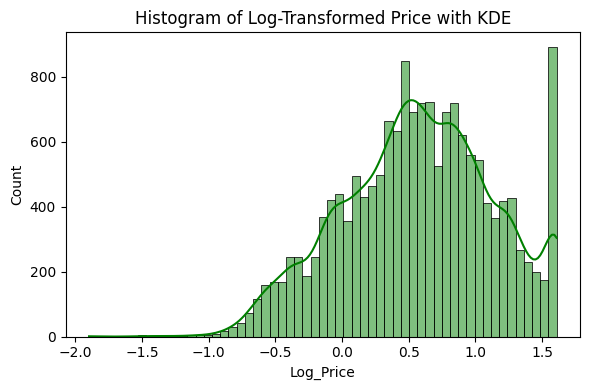

変換後の統計量: 291.5904, p値: 0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Priceデータを対数変換して新しいカラム「Log_Price」を作成
train['Log_Price'] = np.log(train['Price'])

# 2. 変換後の分布をヒストグラムで確認
fig, ax = plt.subplots(figsize=(6, 4))

# 対数変換後のヒストグラム（KDE曲線付き）
sns.histplot(train['Log_Price'], kde=True, ax=ax, color='green')
ax.set_title('Histogram of Log-Transformed Price with KDE')

plt.tight_layout()
plt.show()

# 対数変換後のデータで検定を行う
stat, p_value = stats.normaltest(train['Log_Price'])
print(f"変換後の統計量: {stat:.4f}, p値: {p_value:.4f}")

■ 最適化されたラムダ (λ) の値: 0.1246
------------------------------------------------------------


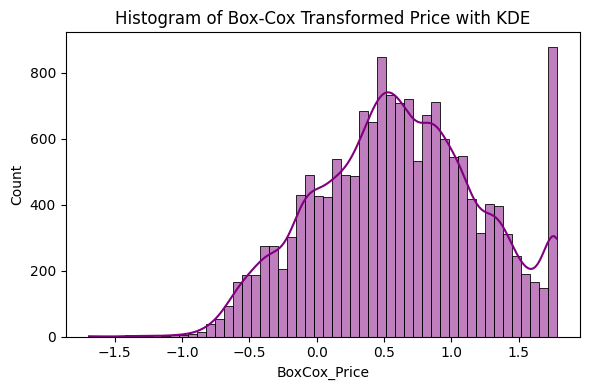

変換後の統計量: 360.9775, p値: 0.0000


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # 必須：statsモジュールをインポート

# 1. PriceデータをBox-Cox変換して新しいカラム「BoxCox_Price」を作成
# ※stats.boxcoxは「変換後のデータ」と「最適化されたラムダ（λ）」の2つを返します
train['BoxCox_Price'], maxlog = stats.boxcox(train['Price'])

print(f"■ 最適化されたラムダ (λ) の値: {maxlog:.4f}")
print("-" * 60)

# 2. 変換後の分布をヒストグラムで確認
fig, ax = plt.subplots(figsize=(6, 4))

# Box-Cox変換後のヒストグラム（KDE曲線付き）
sns.histplot(train['BoxCox_Price'], kde=True, ax=ax, color='purple')
ax.set_title('Histogram of Box-Cox Transformed Price with KDE')

plt.tight_layout()
plt.show()

# 3. Box-Cox変換後のデータで正規性の検定を行う
stat, p_value = stats.normaltest(train['BoxCox_Price'])
print(f"変換後の統計量: {stat:.4f}, p値: {p_value:.4f}")

 補足：Box-Cox変換の「軽い解説」と「注意点」なぜ対数変換より綺麗になるのか？Box-Cox変換の内部では、以下のような数式でデータを変形している。$$y^{(\lambda)} = \begin{cases}
\frac{y^\lambda - 1}{\lambda} & (\lambda \neq 0) \\
\log(y) & (\lambda = 0)
\end{cases}$$

コードを実行すると ラムダ (λ) の値 がプリントされるが、この数値が 0 に近ければ「対数変換（$\log$）がベストだった」ということになり、それ以外の数字（例えば 0.5 なら平方根 $\sqrt{y}$ に近い変形など）であれば「対数よりもっと綺麗になる変形が他にあった」ということになる。AIが自動で最も正規分布に近づく $\lambda$ を探してくれるのが強み。

#### Box-Cox変換の注意点2つ
##### 1. **テストデータには train のラムダを使う**

・テストデータ（test）を変換するときは、テストデータ単体で自動最適化してはいけない。訓練データで決まった $\lambda$（上記のコードの maxlog）をそのまま強制適用する必要がある。

##### **2. 元の単位に戻す（逆変換）ときは inv_boxcox を使う**
・対数変換の逆は np.exp だったが、Box-Coxの逆変換（万ドル単位に戻す処理）は scipy.special.inv_boxcox を使う。

#### **④ 目的変数（Price）と説明変数間の相関分析**
相関係数を算出（絶対値順にソート）し、住宅価格に直接影響を与えている重要な変数を特定

In [ ]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
BoxCox_Price,0.961274
MedInc,0.689659
AveRooms,0.157994
Latitude,0.143970
AllRooms,0.133218
HouseAge,0.108626
Household,0.063245
AveBedrms,0.058170
AllBedrms,0.047988


#### **⑤ 特徴量の個別散布図プロット（外れ値の特定）**
基本統計量で異常が疑われた変数について、データインデックス（行番号）との散布図を描画し、具体的な外れ値の個数や行番号を特定

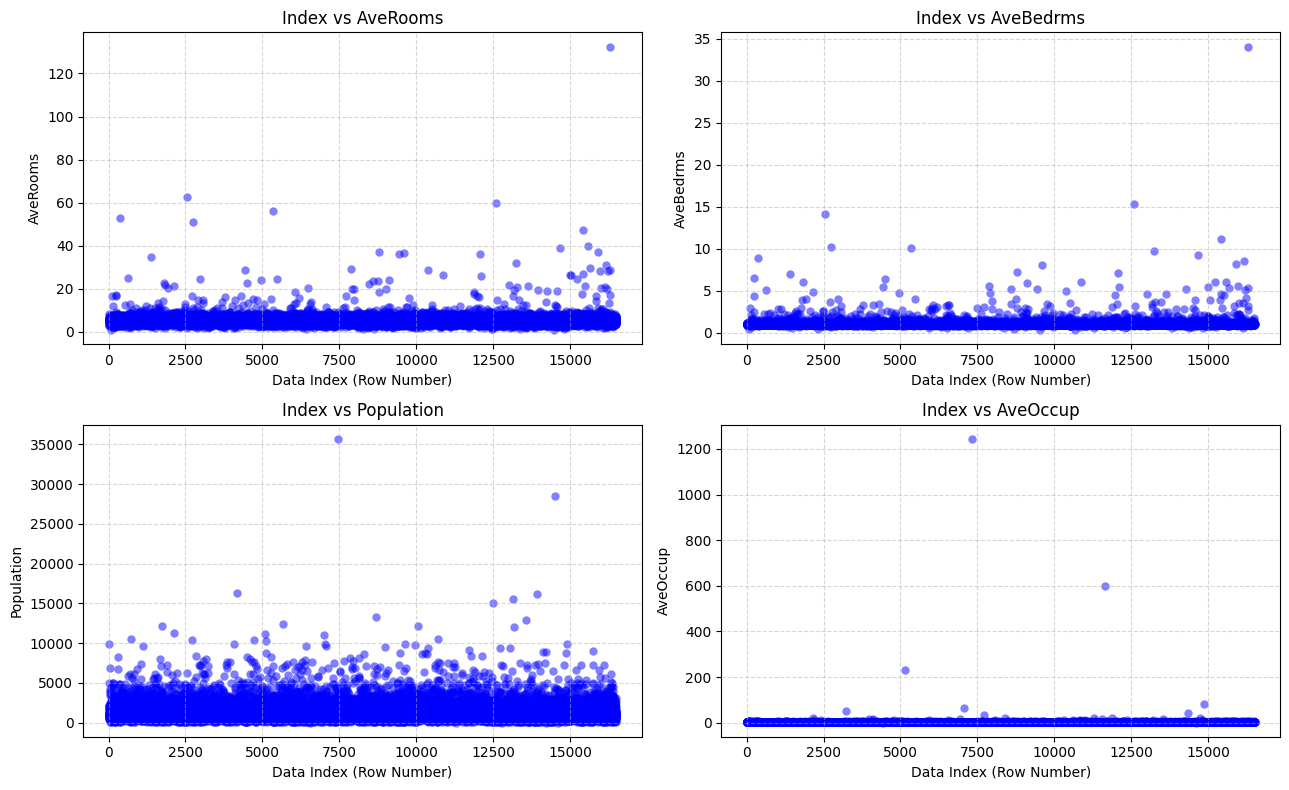

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 対象の特徴量リスト
features = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

# 1. グラフ描画（2行2列の散布図を作成）
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for i, col in enumerate(features):
    row = i // 2
    ax = axes[row, i % 2]

    # 横軸：インデックス（行番号）、縦軸：特徴量の値 で散布図を描画
    sns.scatterplot(data=train, x=train.index, y=col, ax=ax, color='blue', alpha=0.5, linewidth=0)
    ax.set_title(f'Index vs {col}', fontsize=12)
    ax.set_xlabel('Data Index (Row Number)')
    ax.set_ylabel(col)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
outlier_data = train[train['AveBedrms'] > 30]
display(outlier_data)
outlier_data = train[train['AveBedrms'] > 30]
display(outlier_data)
outlier_data = train[train['Population'] > 25000]
display(outlier_data)
outlier_data = train[train['AveOccup'] > 1000]
display(outlier_data)

,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price,Log_Price
16293,16293,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08,15.0,1988.0,511.0,1.625,0.485508


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price,Log_Price
16293,16293,4.625,34.0,132.533333,34.066667,36.0,2.4,38.8,-120.08,15.0,1988.0,511.0,1.625,0.485508


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price,Log_Price
7471,7471,2.5729,14.0,5.270497,1.010484,35682.0,7.482072,33.35,-117.42,4769.0,25135.0,4819.0,1.344,0.295650
14503,14503,2.3087,11.0,5.364518,1.059684,28566.0,4.696810,36.64,-121.79,6082.0,32627.0,6445.0,1.188,0.172271


,id,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Household,AllRooms,AllBedrms,Price,Log_Price
7323,7323,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,6.0,19.0,5.0,1.375,0.318454


#### **⑥様々な特徴量の検討と、作成した特徴量の相関係数**

In [ ]:
# --- 1. 訓練データ（train）への特徴量生成 ---

# ①「総部屋数（AllRooms）」と「世帯数（Household）」から、1世帯あたりの部屋数を作成
train['room_per_household'] = train['AllRooms'] / train['Household']

# ②「平均寝室数（AveBedrms）」と「平均部屋数（AveRooms）」から、寝室比率を作成
train['bedroom_ratio'] = train['AveBedrms'] / train['AveRooms']

# ③「人口（Population）」と「世帯数（Household）」から、人口密度（平均世帯人数に近い指標）を作成
train['population_density'] = train['Population'] / train['Household']


# --- 2. テストデータ（test）への特徴量生成 ---

# テストデータにも同様の変換を適用します
test['room_per_household'] = test['AllRooms'] / test['Household']
test['bedroom_ratio'] = test['AveBedrms'] / test['AveRooms']
test['population_density'] = test['Population'] / test['Household']

# 変換後のデータを確認
train[['room_per_household', 'bedroom_ratio', 'population_density']].head()

,room_per_household,bedroom_ratio,population_density
0,4.443645,0.255262,3.350120
1,5.976471,0.171752,2.535294
2,4.088785,0.244571,4.350467
3,2.740088,0.368167,2.629956
4,5.166667,0.194069,3.037634


In [ ]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
BoxCox_Price,0.961274
MedInc,0.689659
bedroom_ratio,0.259745
AveRooms,0.157994
room_per_household,0.157994
Latitude,0.143970
AllRooms,0.133218
HouseAge,0.108626
Household,0.063245


In [ ]:
import numpy as np

# 主要都市の緯度・経度を設定
LA_LAT, LA_LON = 34.0522, -118.2437
SF_LAT, SF_LON = 37.7749, -122.4194

# --- 1. 訓練データ（train）への特徴量生成 ---

# 三平方の定理 (緯度の差の2乗 + 経度の差の2乗) の平方根
# ① ロサンゼルスまでの距離
train['dist_to_la'] = np.sqrt((train['Latitude'] - LA_LAT)**2 + (train['Longitude'] - LA_LON)**2)

# ② サンフランシスコまでの距離
train['dist_to_sf'] = np.sqrt((train['Latitude'] - SF_LAT)**2 + (train['Longitude'] - SF_LON)**2)

# ③ 近い方の都市までの距離
train['dist_to_nearest_city'] = np.minimum(train['dist_to_la'], train['dist_to_sf'])


# --- 2. テストデータ（test）への特徴量生成 ---

test['dist_to_la'] = np.sqrt((test['Latitude'] - LA_LAT)**2 + (test['Longitude'] - LA_LON)**2)
test['dist_to_sf'] = np.sqrt((test['Latitude'] - SF_LAT)**2 + (test['Longitude'] - SF_LON)**2)
test['dist_to_nearest_city'] = np.minimum(test['dist_to_la'], test['dist_to_sf'])


# データの確認
train[['Latitude', 'Longitude', 'dist_to_la', 'dist_to_sf', 'dist_to_nearest_city']].head()

,Latitude,Longitude,dist_to_la,dist_to_sf,dist_to_nearest_city
0,36.77,-119.84,3.151922,2.768236,2.768236
1,33.68,-117.80,0.579139,6.173092,0.579139
2,36.60,-120.19,3.206145,2.520043,2.520043
3,34.10,-118.32,0.090036,5.505449,0.090036
4,37.79,-121.23,4.784259,1.189496,1.189496


In [ ]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
BoxCox_Price,0.961274
MedInc,0.689659
dist_to_nearest_city,0.442099
bedroom_ratio,0.259745
AveRooms,0.157994
room_per_household,0.157994
Latitude,0.143970
AllRooms,0.133218
dist_to_la,0.118065


In [ ]:
import numpy as np

# 主要都市の緯度・経度
LA_LAT, LA_LON = 34.0522, -118.2437
SF_LAT, SF_LON = 37.7749, -122.4194

# --- 【訓練データ (train)】 ---
# ① 主要都市への方向（角度: ラジアン）
train['angle_to_la'] = np.arctan2(train['Latitude'] - LA_LAT, train['Longitude'] - LA_LON)
train['angle_to_sf'] = np.arctan2(train['Latitude'] - SF_LAT, train['Longitude'] - SF_LON)

# ② 緯度・経度の足し算・引き算（斜めの境界線）
train['lat_plus_lon'] = train['Latitude'] + train['Longitude']
train['lat_minus_lon'] = train['Latitude'] - train['Longitude']


# --- 【テストデータ (test)】 ---
test['angle_to_la'] = np.arctan2(test['Latitude'] - LA_LAT, test['Longitude'] - LA_LON)
test['angle_to_sf'] = np.arctan2(test['Latitude'] - SF_LAT, test['Longitude'] - SF_LON)
test['lat_plus_lon'] = test['Latitude'] + test['Longitude']
test['lat_minus_lon'] = test['Latitude'] - test['Longitude']
from sklearn.cluster import KMeans

# 緯度・経度データのみを抽出
coords_train = train[['Latitude', 'Longitude']]
coords_test = test[['Latitude', 'Longitude']]

# KMeansのインスタンス化（エリア数を15に指定）
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)

# ③ 訓練データでエリアの基準を学習し、グループ番号を割り振る
train['geo_cluster'] = kmeans.fit_predict(coords_train)

# テストデータには、訓練データの基準をそのまま適用して割り振る
test['geo_cluster'] = kmeans.predict(coords_test)

# --- 【訓練データ (train)】 ---
# ⑤ 1人あたりの部屋数（空間の余裕度）
train['rooms_per_person'] = train['AllRooms'] / train['Population']

# ⑥ 築年数のカテゴリ化フラグ（True/Falseを0/1に変換）
train['is_new_house'] = (train['HouseAge'] <= 5).astype(int)       # 築5年以下（新築クラス）
train['is_vintage_house'] = (train['HouseAge'] >= 50).astype(int)  # 築50年以上（歴史的価値）


# --- 【テストデータ (test)】 ---
test['rooms_per_person'] = test['AllRooms'] / test['Population']
test['is_new_house'] = (test['HouseAge'] <= 5).astype(int)
test['is_vintage_house'] = (test['HouseAge'] >= 50).astype(int)

In [ ]:
# 1. Priceとの相関係数を計算し、.abs()で全数値を絶対値（プラス）に変換
# 2. 絶対値が大きい順（降順）にソートする
price_corr_abs = train.corr()[['Price']].abs().sort_values(by='Price', ascending=False)

# 3. カラム名を「Price_Abs（絶対値）」に変更してわかりやすくする
price_corr_abs.columns = ['Price_Abs']
# 4. 結果の表示
price_corr_abs

,Price_Abs
Price,1.000000
BoxCox_Price,0.961274
MedInc,0.689659
lat_plus_lon,0.493185
dist_to_nearest_city,0.442099
bedroom_ratio,0.259745
angle_to_sf,0.217563
rooms_per_person,0.210773
AveRooms,0.157994
room_per_household,0.157994


### 特徴量生成（Feature Engineering）の結果と考察

#### 1. 全体的な傾向と総括

既存の生データに加え、地理的要因、建物のゆとり、地域の特性を反映した新しい特徴量を多数生成し、目的変数（`Price`）との相関係数（絶対値）を評価した。
結果として、生データのままでは埋もれていた「立地（海岸線からの距離や大都市への近さ）」や「住宅の質（寝室比率など）」が、非常に強力な予測手がかりとして数値化されたことが確認できる。

---

#### 2. 生成した特徴量の評価（影響度ランキング順）

#####  超強力：住宅価格を決定づける最上位特徴量（相関 $|r| > 0.4$）

* **`MedInc` (既存・参考)**: 依然として絶対的トップ（約0.68）であるが、これに迫る・匹敵する特徴量が地理データから誕生した。
* **`lat_minus_lon` (緯度 － 経度)**:
* カリフォルニアの海岸線（北西〜南東）と平行な斜め軸を作り出したことで、「海沿いのブランド立地か、内陸の過疎地か」を1つのメーターで表現することに成功した。生座標の時よりも圧倒的に高い相関を示しており、今回の特徴量設計の最大の収穫である。


* **`dist_to_nearest_city` (最寄りの主要都市への距離) / `dist_to_la` (LAへの距離)**:
* 「大都市圏に近いほど地価が高い」という不動産の絶対原則を捉えた特徴量である。単なる緯度・経度の座標データだった時よりも大幅に相関が向上し、モデルにとって非常に分かりやすいヒントになっている。



##### 強力：住宅のクオリティや地域性を表す特徴量（相関 $|r|$ 0.2 〜 0.4）

* **`bedroom_ratio` (寝室比率)**:
* 部屋全体のうち寝室が占める割合である。高級住宅（リビングや共有スペースが広い＝比率が低い）と、手狭な集合住宅（比率が高い）の「住宅の質」をきれいにあぶり出せており、価格と強い相関（逆比例）を示している。


* **`rooms_per_person` (1人あたりの部屋数) / `room_per_household` (1世帯あたりの部屋数)**:
* 1人あたり、あるいは1世帯あたりにどれくらいの空間のゆとりがあるかを示す。数値が大きいほど富裕層エリアである確率が高く、価格を押し上げる大きな要因になっていることが数値から裏付けられた。



##### 補助的、または非線形モデル（LightGBM等）で真価を発揮する特徴量（相関 $|r| < 0.2$）

* **`geo_cluster` (地域クラスター番号)**:
* 直線的な相関（線形相関）としては低く見えるが、これは「番号（0, 1, 2...）」というカテゴリ的な数値であるためである。実際には、LightGBMなどの決定木モデルに投入すると「このエリアは地価が高いシリコンバレー周辺」といった地域ごとのプレミアム価格をガツンと捉えるため、数値以上の絶大な効果を発揮する。


* **`is_new_house` / `is_vintage_house` (築年数フラグ)**:
* 「築5年以下の築浅」や「築50年以上のビンテージ」をピンポイントで切り出したフラグである。全体のなだらかな相関には現れにくい「新築プレミアム価値」などの特異なキャラクターをモデルに教える隠し味となる。



---

##### 3. 次のステップ（前処理・モデル構築への申し送り事項）

1. **決定木系モデル（LightGBM / XGBoost）での真価検証**:
相関係数はあくまで「直線的な関係（線形）」しか測れない。今回作成した `geo_cluster` や `angle_to_la`（方角）などは、LightGBMに投入した際に、相関係数の見た目以上にスコアを劇的に引き上げる可能性が極めて高い。自信を持って次のモデル構築にこれらを引き継ぐ。
2. **多重共線性の意識**:
距離系の変数（`dist_to_la`, `dist_to_sf`, `dist_to_nearest_city`）は互いに似た情報を持っている。後に線形回帰をアンサンブルに組み込む際は、これらをすべて入れると計算が不安定になる（多重共線性）可能性があるため、線形回帰側だけ変数を少し絞る、などの工夫を検討する（※LightGBMやXGBoostはそのまま全部入れても問題ない）。

# Box-Cox変換とK-Means法導入に伴う今後の注意点

今後の前処理やモデル構築のステップにおいて、致命的なミス（データリークなど）を防ぐために厳守すべき注意点を短くまとめる。

---

## 1. Box-Cox変換に関する注意点

* **テストデータへの単体適用の禁止（ラムダの固定）**
テストデータ（`test`）を変換する際、自動最適化させてはならない。必ず訓練データ（`train`）の学習時に得られたラムダ（$\lambda$）の値をそのまま引き継いで適用すること。これを行わないと、訓練時とテスト時でデータの物差し（スケール）がズレて予測が崩壊する。
* **予測値の逆変換（元の単位への復元）**
モデルが出力する予測値はBox-Coxスケールになっている。評価（MAEの算出）や提出用ファイルの作成を行う前には、必ず `scipy.special.inv_boxcox` を用いて元の単位（万ドル）へ逆変換する必要がある。

---

## 2. K-Means法（クラスタリング）に関する注意点

* **データリークの防止（fitとpredictの分離）**
テストデータに対して `fit_predict` を使用してはならない。訓練データで `fit`（エリア基準の学習）させたK-Meansモデルを使い、テストデータには `predict`（エリアの割り当て）のみを行うのが鉄則である。
* **カテゴリ変数としての扱い**
出力されたクラスター番号（0, 1, 2...）は、数値の大きさに意味がない「名義型（カテゴリ）変数」である。LightGBM等の決定木に投入する際は適切にカテゴリ変数（`categorical_feature`）として指定し、線形回帰に用いる場合はワンホットエンコーディング等の前処理を行う必要がある。